# Рекомендательная система «Монеты для клиента»
**Проект:** увеличение продаж монет за счёт релевантного предложения материалам клиенту.

**Источники**
* ТЗ (Google Docs): https://docs.google.com/document/d/1fdd9aYCvNGX_EtA3dTKB1WYdVLTlcndMjRSFzBRY9fY/edit
* Данные (Google Sheets): https://docs.google.com/spreadsheets/d/1CNVaym30EWI8uH31SA0xmRUZndCC4DqLZyVmOiRY5R8/edit

**Три критерия отбора (ТЗ, п. 2.1)**

| # | Критерий | Как реализован |
|---|---|---|
| 1 | Новизна | Жёсткий фильтр: ГП2 и мотив монеты отсутствуют среди покупок клиента |
| 2 | Соответствие интересам | Content-based профиль: доли покупок по княжеству, князю, номиналу, мотиву описания и редкости |
| 3 | Соответствие бюджету | Жёсткий фильтр: цена внутри бюджетного коридора клиента (медиана ± расширение IQR) |

**Итоговая релевантность**

$$\text{score} = 0.20\cdot\text{Новизна} + 0.50\cdot\text{Профиль} + 0.30\cdot\text{Бюджет}$$

**Этапы ТЗ в этом ноутбуке:** 2 «Аудит и подготовка данных» → 3 «Прототип модели» →
4 «Валидация и настройка» → материал для этапов 5 «Пилот» и 7 «Оценка результатов».

In [1]:
import sys, pathlib

# ноутбук лежит в notebooks/, работаем из корня репозитория
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from recommender import config as C
from recommender.pipeline import run_pipeline

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 90)
%matplotlib inline

# Полный прогон: аудит → профили → рекомендации → offline-тест → отчёты
res = run_pipeline(input_path=C.EXCEL_PATH, out_dir="reports", top_k=C.TOP_K, verbose=False)
print("Готово. Артефакты:", sorted(p.name for p in pathlib.Path('reports').glob('*')) )

Готово. Артефакты: ['backtest_details.csv', 'catalog_enriched.csv', 'client_profiles.csv', 'data_quality_report.csv', 'metrics.csv', 'recommendations.xlsx', 'sensitivity.csv', '~$Дашборд.xlsx', '~$Рекомендации_для_вставки.xlsx', 'Дашборд.xlsx', 'Рекомендации_для_вставки.xlsx']


## 1. Данные

Единая книга, две закладки (ТЗ, п. 4.1): **Сделки** (статусы монет + история сделок) и
**Клиенты** (имя → уникальный ID). Статус `доступна` = монета является кандидатом
для рекомендации.

In [2]:
cat = res["каталог"]
print(f"Всего монет: {len(cat)}")
print(cat["СТАТУС"].value_counts().to_string())
print(f"\nКлиентов: {len(res['профили'])}, сделок: "
      f"{(cat['СТАТУС'] == 'продана').sum()}")
cat.head(8)[["ID монеты", "СТАТУС", "ГП2", "Княжество", "Князь", "номинал",
             "описание", "R", "продажа", "кому"]]

Всего монет: 57
СТАТУС
продана     47
доступна    10

Клиентов: 5, сделок: 47


,ID монеты,СТАТУС,ГП2,Княжество,Князь,номинал,описание,R,продажа,кому
0,162172af-d06e-4e60-9406-eaccb3e93462,продана,3610C,Можайск,АД,денга,кентавр/строчник,5.0,14000.0,Alexan
1,5192434d-e1a5-44ef-acc0-fc91ebfaf728,продана,NEW,Можайск,АД,денга,Всадник с драконом/строчник,1.0,120000.0,Alexan
2,3c4c1026-96a9-470a-ad5e-69101f621c12,продана,1111,Москва,ДД,денга,Воин влево/подражание,4.0,40000.0,Alexan
3,11cd3f1d-8301-42fc-97a0-3ddb5efc703c,продана,4745,Ростов,Фёдор,денга,Танцоры/князь с мечом,3.0,95000.0,Alexan
4,e4c74b50-0924-48cc-8d00-eba6dc6b07be,продана,None,Серпухов,СВ,денга,Двуименка Самсон/строчник,NaN,14000.0,Alexan
5,b818e413-09e4-4b47-a061-6f93c0c72946,продана,None,Серпухов,СВ,денга,Двуименка Самсон/строчник,NaN,15000.0,Alexan
6,38a9ad10-6eeb-48e1-a92f-27329f35971c,продана,1135А,Москва,ВД,денга,Янус,4.0,39000.0,Alexan
7,78672c3c-6af1-43cd-ba58-dfc4c7cf1316,продана,1580,Москва,ВД,денга,собачки,2.0,45000.0,Alexan


In [3]:
# Заполненность атрибутов у кандидатов (доступных монет)
avail = cat[cat["СТАТУС"] == C.STATUS_AVAILABLE]
fill = avail[C.DEAL_COLUMNS].notna().mean().round(2)
print("Заполненность полей у доступных монет (доля непустых):")
print(fill.to_string())
print("\nКак восстанавливаются недостающие значения:")
print(avail[["ГП2", "Княжество", "номинал", "R", "цена_рекомендации",
             "цена_источник", "цена_аналогов"]].to_string(index=False))

Заполненность полей у доступных монет (доля непустых):
ID монеты       1.0
СТАТУС          1.0
ГП2             0.9
Княжество       1.0
Князь           0.7
номинал         1.0
описание        0.0
R               1.0
вход            0.0
у кого          0.0
ДАТА ПОКУПКИ    0.0
ДАТА ПРОДАЖИ    0.0
продажа         0.0
ID клиента      0.0
кому            0.0
маржа           0.0
%               0.0

Как восстанавливаются недостающие значения:
  ГП2 Княжество   номинал   R  цена_рекомендации   цена_источник  цена_аналогов
1000A    Москва     денга 4.0            45000.0 княжество+князь              2
 3004  Серпухов     денга 1.0            50000.0        ГП2 3004              1
 1575      СНВК      пуло 2.0            25000.0        ГП2 1575              1
  NEW      СНВК      пуло 2.0            25000.0       княжество              3
 None   Микулин     денга 2.0            35000.0    весь каталог             47
 1111    Москва     денга 4.0            40000.0        ГП2 1111              1


## 2. Аудит и подготовка данных (этап 2)

30 автоматических проверок по требованиям п. 4.2 ТЗ: фиксированный набор столбцов,
обязательные поля, консистентность статусов, справочники, UUID, даты, контроль
расчёта маржи и %. Полный отчёт: `reports/data_quality_report.csv`.

In [4]:
audit = res["аудит"]
print(audit["уровень"].value_counts().to_string(), "\n")
pd.DataFrame(audit[audit["уровень"] != "OK"])[
    ["код", "уровень", "проверка", "значение", "комментарий"]]

уровень
OK      26
WARN     3
FAIL     1 



,код,уровень,проверка,значение,комментарий
11,REQS-01,FAIL,Обязательное поле в сделке: ДАТА ПОКУПКИ,47/47 (100%),У 47 проданных монет не заполнено «ДАТА ПОКУПКИ» — расчёт KPI по этому полю невозможен.
18,REQA-01,WARN,Атрибуты доступных монет (кандидатов),пустых ячеек: 14 из 60,"Не заполнено: ГП2: 1, Князь: 3, описание: 10. Цена и мотив восстанавливаются по аналог..."
19,FMT-01,WARN,Дата закупки ≤ даты продажи (формат д.м.г),0/0 пар дат,Ни одна дата закупки не заполнена — проверить согласованность дат и рассчитать KPI «за...
26,DICT-03,WARN,Дубли номеров ГП2 (разные ID монет),8/57 (14%),"Проверьте, не одна ли это монета под двумя ID."


In [5]:
# FAIL — что обязательно закрыть до пилота
fails = audit[audit["уровень"] == "FAIL"]
if len(fails):
    for _, r in fails.iterrows():
        print(f"[{r['код']}] {r['проверка']}\n   → {r['значение']}\n   {r['комментарий']}\n")
else:
    print("Критичных нарушений нет")

[REQS-01] Обязательное поле в сделке: ДАТА ПОКУПКИ
   → 47/47 (100%)
   У 47 проданных монет не заполнено «ДАТА ПОКУПКИ» — расчёт KPI по этому полю невозможен.



## 3. Профили клиентов (критерии 2 и 3)

Профиль = исторические покупки клиента. Отсюда:
* **интересы** — доли покупок по справочникам и частота слов в описаниях;
* **бюджет** — коридор цен покупок: `min(Q1 − IQR, медиана·0.5) … max(Q3 + IQR, медиана·1.5)`;
* **новизна** — множество купленных ГП2 и мотивов описания.

In [6]:
profiles = res["профили"]
fmt = {"Бюджет, низ": lambda v: f"{v:,.0f}", "Бюджет, медиана": lambda v: f"{v:,.0f}",
       "Бюджет, верх": lambda v: f"{v:,.0f}"}
profiles.style.format(fmt, na_rep="—")

,ID клиента,Клиент,Сделок,Первая сделка,Последняя сделка,"Бюджет, низ","Бюджет, медиана","Бюджет, верх",Диапазон цен,Любимое княжество,Любимый князь,Любимый номинал,Частый мотив,Медианная редкость R
0,a4bc418f-2729-4431-bed3-7c123d84a2fe,Alexan,13,2025-12-01 00:00:00,2026-03-19 00:00:00,0,"41,000","118,000","14,000 – 120,000",москва (38%),вд (31%),денга (92%),"строчник, подражание, двуименка",2.000000
1,28b8882a-8843-4d87-8ed9-c2f47c82cde7,Гогер,6,2026-03-28 00:00:00,2026-05-12 00:00:00,"11,250","22,500","37,500","15,000 – 35,000",можайск (83%),ад (100%),полуденга (83%),"воин, рамке, голова",1.000000
2,d2209f0c-56c0-4bbc-a6f7-ed4bf639eec5,Городен,3,2026-05-21 00:00:00,2026-06-08 00:00:00,"21,000","52,000","88,500","35,000 – 80,000",тверь (67%),мб (67%),денга (100%),"строчник, охота, голова",1.500000
3,c71269f7-e745-45ec-8fc9-186b8271d70a,Лейбов,2,2026-06-17 00:00:00,2026-06-26 00:00:00,"6,250","12,500","18,750","12,000 – 13,000",москва (100%),вд (100%),денга (100%),"оставите, безумье, живы",—
4,c12aca37-9c5e-4167-bd84-a68f382d657a,Шувалов,23,2026-07-05 00:00:00,2026-09-29 00:00:00,0,"35,000","75,000","10,000 – 100,000",тверь (26%),вд (26%),денга (78%),"воин, влево, строчник",1.000000


## 4. Рекомендации (этап 3 — MVP)

Кандидаты — только монеты со статусом `доступна`. Сначала применяются жёсткие
фильтры «и» (новизна и бюджет), затем ранжирование по итоговой релевантности.
Если строгих кандидатов меньше K — бюджет расширяется до ±60% от медианы, и такая
строка помечается как `эскалация`. Критерий новизны никогда не ослабляется.

In [7]:
recs = res["рекомендации"]
show = ["Клиент", "ранг", "ГП2", "Княжество", "Князь", "номинал", "цена, ₽",
        "Новизна", "Профиль", "Бюджет", "Итог", "Бюджет коридор"]
recs[show].style.format({"цена, ₽": "{:,.0f}", "Новизна": "{:.2f}",
                         "Профиль": "{:.2f}", "Бюджет": "{:.2f}", "Итог": "{:.3f}"})

,Клиент,ранг,ГП2,Княжество,Князь,номинал,"цена, ₽",Новизна,Профиль,Бюджет,Итог,Бюджет коридор
0,Alexan,1,1300,Москва,ВД,денга,"40,000",1.00,0.99,0.98,0.989,ок
1,Alexan,2,1000A,Москва,ДД,денга,"45,000",1.00,0.81,0.93,0.882,ок
2,Alexan,3,3004,Серпухов,Храбрый,денга,"50,000",1.00,0.50,0.85,0.703,ок
3,Alexan,4,None,Микулин,None,денга,"35,000",1.00,0.42,0.90,0.678,ок
4,Alexan,5,7262А,Тверь,МБ,денга,"52,000",1.00,0.33,0.81,0.611,ок
5,Гогер,1,1575,СНВК,None,пуло,"25,000",1.00,0.26,0.81,0.571,ок
6,Гогер,2,NEW,СНВК,None,пуло,"25,000",1.00,0.26,0.81,0.571,ок
7,Гогер,3,7100A,Тверь,БА,денга,"20,000",1.00,0.17,0.81,0.530,ок
8,Гогер,4,None,Микулин,None,денга,"35,000",1.00,0.19,0.05,0.309,ок
9,Гогер,5,3004,Серпухов,Храбрый,денга,"50,000",1.00,0.17,0.00,0.287,эскалация +122%


In [8]:
# Обоснование релевантности — что менеджер видит в карточке рекомендации
example = recs[recs["Клиент"] == "Шувалов"].head(3)
for _, r in example.iterrows():
    print(f"{r['ранг']}. {r['ГП2']} | {r['Княжество']} / {r['Князь']} / {r['номинал']} "
          f"| ~{r['цена, ₽']:,.0f} ₽ | итог {r['Итог']:.3f}")
    print(f"   {r['Обоснование']}\n")

1. 1300 | Москва / ВД / денга | ~40,000 ₽ | итог 0.954
   Профиль: княжество Москва — 26% ваших покупок; князь ВД — 26% ваших покупок; номинал денга — 78% ваших покупок | Бюджет: ~40,000 ₽ внутри коридора 0 – 75,000 ₽ (медиана ваших покупок 35,000 ₽) | Новизна: ГП2 1300 в коллекции отсутствует

2. 1111 | Москва / ДД / денга | ~40,000 ₽ | итог 0.847
   Профиль: княжество Москва — 26% ваших покупок; номинал денга — 78% ваших покупок; R=4 при вашей медиане 1 | Бюджет: ~40,000 ₽ внутри коридора 0 – 75,000 ₽ (медиана ваших покупок 35,000 ₽) | Новизна: ГП2 1111 в коллекции отсутствует

3. 7100A | Тверь / БА / денга | ~20,000 ₽ | итог 0.840
   Профиль: княжество Тверь — 26% ваших покупок; номинал денга — 78% ваших покупок; R=1 при вашей медиане 1 | Бюджет: ~20,000 ₽ внутри коридора 0 – 75,000 ₽ (медиана ваших покупок 35,000 ₽) | Новизна: ГП2 7100А в коллекции отсутствует



In [9]:
# Структура пула: сколько кандидатов рассматривалось и сколько прошло бюджет
pool_info = (recs.groupby("Клиент")
             .apply(lambda g: pd.Series({"кандидатов в пуле": g["пул кандидатов"].max(),
                                         "прошло бюджет": g["прошло бюджет"].max(),
                                         "в выдаче": len(g)}),
                    include_groups=False)
             .reset_index())
pool_info

,Клиент,кандидатов в пуле,прошло бюджет,в выдаче
0,Alexan,9,9,5
1,Гогер,9,4,5
2,Городен,10,8,5
3,Лейбов,10,0,5
4,Шувалов,8,8,5


## 5. Валидация на исторических данных (этап 4)

**Метод temporal leave-one-out.** Для каждой исторической сделки *(клиент, монета,
дата T)*: профиль строится только по сделкам раньше T; в пул попадают монеты,
не проданные на момент T (и не купленные этим клиентом); система ранжирует пул и
замечается, на каком месте оказалась реально купленная монета.

**Метрики:** *покрытие* — доля сделок, где цель прошла все три фильтра;
*HR@K* — доля сделок, где цель попала в топ-K; *MRR* — обратный ранг цели;
*NDCG@K* — взвешенный по позиции ранг. Сделка, не прошедшая фильтры, считается
промахом (иначе покрытие «съедало бы» качество).

**Бейслайны:** популярность категории, «наугад» (аналитическое матожидание) —
первые два даются в двух вариантах: без фильтров и с теми же фильтрами, что и модель.

In [10]:
metrics = res["метрики"]
cols = ["метод", "оценено сделок", "покрытие (прошла фильтры)",
        "HR@1", "HR@3", "HR@5", "HR@10", "MRR", "NDCG@5"]
metrics[cols].style.format({"покрытие (прошла фильтры)": "{:.1%}",
                            "HR@1": "{:.3f}", "HR@3": "{:.3f}", "HR@5": "{:.3f}",
                            "HR@10": "{:.3f}", "MRR": "{:.3f}", "NDCG@5": "{:.3f}"})

,метод,оценено сделок,покрытие (прошла фильтры),HR@1,HR@3,HR@5,HR@10,MRR,NDCG@5
0,"Модель (3 критерия, строгие фильтры)",42,73.8%,0.071,0.167,0.262,0.357,0.158,0.161
1,Модель (скоринг без фильтров),42,100.0%,0.071,0.190,0.333,0.476,0.192,0.192
2,Бейслайн: популярность категории,42,100.0%,0.048,0.143,0.262,0.452,0.172,0.155
3,Бейслайн: популярность (те же фильтры),42,73.8%,0.048,0.143,0.262,0.333,0.147,0.152
4,Бейслайн: наугад,42,100.0%,0.037,0.112,0.187,0.375,0.141,0.111
5,Бейслайн: наугад (те же фильтры),42,73.8%,0.041,0.123,0.200,0.373,0.135,0.119


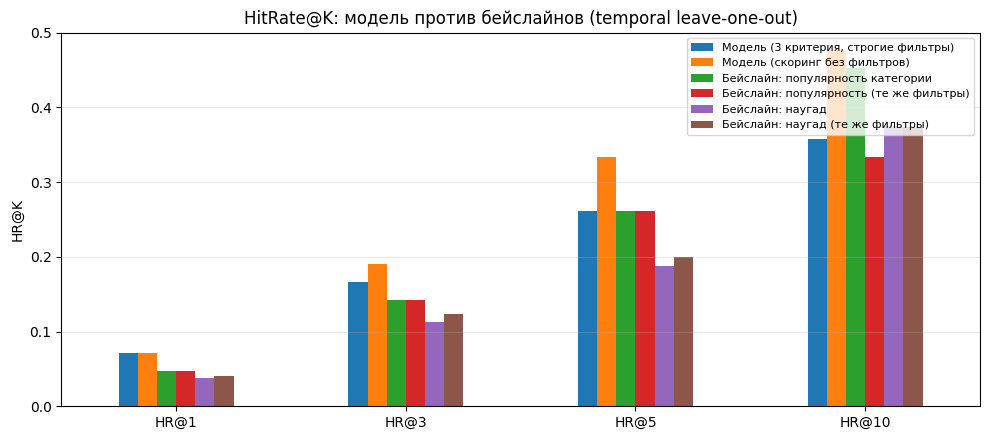

In [11]:
# Сравнение HR@K: модель против бейслайнов
plot = metrics.set_index("метод")[["HR@1", "HR@3", "HR@5", "HR@10"]]
ax = plot.T.plot(kind="bar", figsize=(10, 4.5), rot=0,
                 title="HitRate@K: модель против бейслайнов (temporal leave-one-out)")
ax.set_ylabel("HR@K")
ax.legend(fontsize=8, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Где фильтры «отсекают» исторические сделки
details = res["детали"]
ok = details[details["статус"] == "ok"].copy()
nov, bud = ok["новизна_ok"].astype(bool), ok["бюджет_ok"].astype(bool)
print(f"Оценено сделок: {len(ok)}; пропущено (первая покупка клиента): "
      f"{len(details) - len(ok)}")
print(f"Прошло фильтр новизны: {nov.mean():.1%} | бюджета: {bud.mean():.1%} "
      f"| обоих: {(nov & bud).mean():.1%}")
print("\nПричины отклонения по новизне:")
print(ok.loc[~nov, "причина фильтра"].dropna().value_counts().to_string())
cov = ok[ok["ранг (модель с фильтрами)"].notna()]
print(f"\nКачество ранжирования СРЕДИ прошедших фильтры (n={len(cov)}):")
print({f"HR@{k}": round(float((cov['ранг (модель с фильтрами)'] <= k).mean()), 3)
       for k in (1, 3, 5, 10)})

Оценено сделок: 42; пропущено (первая покупка клиента): 5
Прошло фильтр новизны: 90.5% | бюджета: 81.0% | обоих: 73.8%

Причины отклонения по новизне:
причина фильтра
мотив «двуименка самсон» уже встречался в ваших покупках     1
мотив «воин» уже встречался в ваших покупках                 1
мотив «барс оглядывается» уже встречался в ваших покупках    1
мотив «воин влево» уже встречался в ваших покупках           1

Качество ранжирования СРЕДИ прошедших фильтры (n=31):
{'HR@1': 0.097, 'HR@3': 0.226, 'HR@5': 0.355, 'HR@10': 0.484}


In [13]:
# Разбивка по клиентам
by_client = ok.groupby("клиент").apply(
    lambda g: pd.Series({
        "сделок": len(g),
        "покрытие": g["ранг (модель с фильтрами)"].notna().mean(),
        "HR@5 (модель)": (g["ранг (модель с фильтрами)"].fillna(1e9) <= 5).mean(),
        "HR@5 (без фильтров)": (g["ранг (модель без фильтров)"] <= 5).mean(),
        "HR@5 (популярность)": (g["ранг (популярность)"] <= 5).mean(),
    }), include_groups=False)
by_client.round(3)

,сделок,покрытие,HR@5 (модель),HR@5 (без фильтров),HR@5 (популярность)
клиент,,,,,
Alexan,12.0,0.750,0.083,0.083,0.167
Гогер,5.0,0.600,0.400,0.600,0.400
Городен,2.0,0.500,0.000,0.500,0.000
Лейбов,1.0,1.000,1.000,1.000,0.000
Шувалов,22.0,0.773,0.318,0.364,0.318


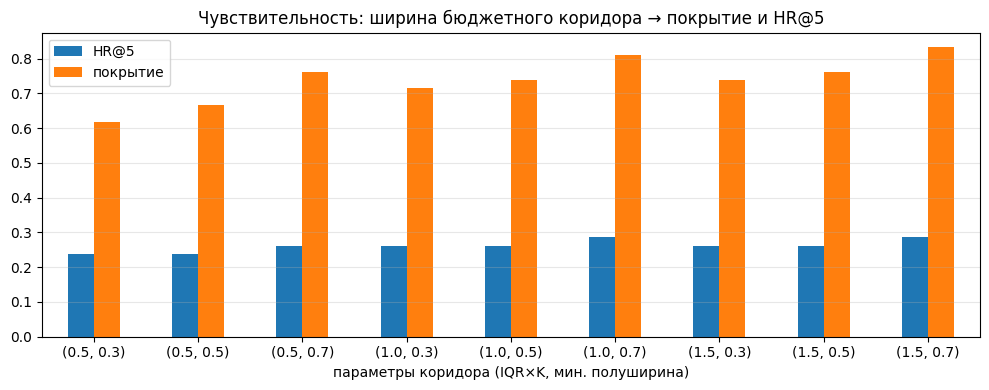

,BUDGET_IQR_K,мин. полуширина коридора,покрытие,HR@3,HR@5,HR@10,MRR,выбрано
4,1.0,0.5,0.7381,0.1667,0.2619,0.3571,0.1585,True


In [14]:
# Анализ чувствительности бюджетного коридора — обоснование выбранных параметров
sens = res["чувствительность"]
ax = sens.pivot_table(index=["BUDGET_IQR_K", "мин. полуширина коридора"],
                      values=["покрытие", "HR@5"]).plot(
    kind="bar", figsize=(10, 4), rot=0,
    title="Чувствительность: ширинa бюджетного коридора → покрытие и HR@5")
ax.set_xlabel("параметры коридора (IQR×K, мин. полуширина)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
sens[sens["выбрано"]]

## 6. KPI, пилот и риски

**KPI (ТЗ, п. 1)** — целевые значения X, Y, Z фиксируются с заказчиком до пилота.
Предлагаемый способ замера:

| KPI | Метрика | Как считаем | Baseline сейчас |
|---|---|---|---|
| X — конверсия предложений в сделки | сделки / выданные рекомендации | в пилоте: менеджер отмечал, была ли рекомендация показана | офлайн-прокси: HR@5 = **0.262** (доля целей в топ-5) |
| Y — срок «закупка → продажа» | среднее число дней | по полям `ДАТА ПОКУПКИ` → `ДАТА ПРОДАШИ` | **не считается**: `ДАТА ПОКУПКИ` не заполнена ни разу (FAIL в аудите) |
| Z — доля продаж по рекомендациям | сделки из топ-K / все сделки | пометка источника сделки | офлайн-прокси: покрытие фильтров = **73.8%** |

**Что даёт офлайн-тест:** модель лучше бейслайнов на точных метриках
(HR@1 0.071 против 0.041/0.048, MRR 0.158 против 0.135/0.147 при одинаковом
покрытии 73.8%), то есть ранжирование действительно отбирает релевантное наверху.

**Риски (ТЗ, п. 6) и как закрываем**
* неполнота данных → аудит 30 проверок + восстановление цен по аналогам;
* нет данных о предпочтениях → профиль строится из фактических покупок;
* устаревание каталога → фильтр статуса `доступна` при каждой генерации;
* **не закрыт:** `ДАТА ПОКУПКИ` не вносится → KPI Y недоступен; описание и цена
  у кандидатов не заполнены → мотив проверить нельзя, цена оценивается по аналогам.

**Дальше:** этап 5 «Пилот» — ограниченная выборка клиентов, замер X/Y/Z,
затем этап 6 «Промышленный запуск» (регулярное обновление таблиц + автогенерация
рекомендаций) и этап 7 «Оценка результатов».

## 7. Как пользоваться: один запуск и рекомендации в Google Таблице

Для человека, который ведёт таблицу и не работает с терминалом, — **двойной
клик по `Запустить.bat`** (эквивалент `python -m recommender --google
--dashboard --open`): свежая выгрузка → расчёт → файл для вставки рекомендаций
→ Excel-дашборд → открытие результатов с инструкцией «что делать дальше».
Без интернета расчёт не встаёт: берётся последняя локальная копия
`data/coins.xlsx`, и это видно в шапке дашборда.

### 7.1. Рекомендации во вкладку «Рекомендации» (gid=115404378)

Запись в Google Таблицу из кода не выполняется — на неё нужен разрешённый
канал, поэтому система готовит **`reports/Рекомендации_для_вставки.xlsx`**:

| Требование заказчика | Как сделано |
|---|---|
| одна строка = одно предложение «монета → клиенту» | ровно столько строк, сколько пар: 5 клиентов × топ-5 = 25 |
| атрибуты монеты — из вкладки «Сделки» | `ID монеты, ГП2, Княжество, Князь, номинал, описание, R, вход` копируются как есть; где в «Сделках» пусто — остаётся пусто (оценочные значения не подставляются) |
| «за сколько» и «предложено» не заполняются | эти колонки **не входят в файл**: при вставке они не затирают ваши ручные отметки |
| дозапись в конец | пары «монета + клиент», уже существующие во вкладке, исключаются; прежние строки не трогаются |

Вставка: вкладка **«Копировать»** → ячейка A1 → `Ctrl+A` → `Ctrl+C` → в
Google Таблице вкладка **«Рекомендации»** → первая пустая строка → `Ctrl+V`.
Номер этой строки система печатает в инструкции и в консоли при каждом запуске.

### 7.2. Дашборд `reports/Дашборд.xlsx`

Книга Excel, которая сама подтягивает данные из Google Таблицы по ссылке
(`GOOGLE_SHEET_URL` в `recommender/config.py`):

| Лист | Что внутри |
|---|---|
| **Дашборд** | 8 карточек KPI, топ-5 рекомендаций для каждого клиента с обоснованием, 5 диаграмм, предупреждение при FAIL в аудите |
| Рекомендации · Профили клиентов · Каталог монет | таблицы с обоснованиями и оценкой цен |
| Качество данных · Метрики | 30 проверок (OK/WARN/FAIL) и offline-тест |
| Как обновить | инструкция внутри книги — документы открывать не нужно |

In [15]:
# Артефакты проекта
for p in sorted(pathlib.Path("reports").glob("*")):
    print(f"{p.name:32s} {p.stat().st_size:>9,d} байт")

backtest_details.csv                21,196 байт
catalog_enriched.csv                17,434 байт
client_profiles.csv                  1,440 байт
data_quality_report.csv              4,005 байт
metrics.csv                          1,649 байт
recommendations.xlsx                28,344 байт
sensitivity.csv                        560 байт
~$Дашборд.xlsx                         165 байт
~$Рекомендации_для_вставки.xlsx        165 байт
Дашборд.xlsx                        37,836 байт
Рекомендации_для_вставки.xlsx        8,121 байт
